In [ ]:
import torch
import os
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import Subset, DataLoader, random_split, Dataset
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mostafaabla/garbage-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-classification' dataset.
Path to dataset files: /kaggle/input/garbage-classification


In [ ]:
os.listdir(path)

['garbage_classification']

In [ ]:
new_path = os.path.join(path, 'garbage_classification')

os.listdir(new_path)

['metal',
 'white-glass',
 'biological',
 'paper',
 'brown-glass',
 'battery',
 'trash',
 'cardboard',
 'shoes',
 'clothes',
 'plastic',
 'green-glass']

In [ ]:
IMG_SIZE = 64

In [ ]:
class MyTransform(Dataset):
  def __init__(self, subset, transform):
    self.subset = subset
    self.transform = transform

  def __getitem__(self, index):
    x, y = self.subset[index]
    if self.transform:
      x = self.transform(x)
    return x, y

  def __len__(self):
    return len(self.subset)


In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
full_datasets = datasets.ImageFolder(root=new_path)

In [ ]:
val_size = int(0.2 * len(full_datasets))
train_size = len(full_datasets) - val_size

In [ ]:
train_indices, val_indices = random_split(full_datasets, [train_size, val_size])

In [ ]:
train_ds = MyTransform(train_indices, transform=transform)
val_ds = MyTransform(val_indices, transform=transform)

In [ ]:
bs = 32

In [ ]:
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)
valid_dl = DataLoader(val_ds, batch_size=bs, shuffle=False)

In [ ]:
class MyCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.features = nn.Sequential(
      nn.Conv2d(3, 32, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2),

      # Блок 2
      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2),

      # 3
      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2, stride=2),

    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 128),
      nn.ReLU(),
      nn.Dropout(0.6),

      nn.Linear(128, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [ ]:
def init_weights(m):
    if isinstance(m, nn.Conv2d):
        torch.nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            m.bias.data.fill_(0)

    elif isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        m.bias.data.fill_(0.01)

model = MyCNN(12)
model.apply(init_weights)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train(model, num_epochs, train_dl, valid_dl, device):
    loss_hist_train = [0] * num_epochs
    acc_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    acc_hist_valid = [0] * num_epochs

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            pred = model(x)

            loss = loss_fn(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_hist_train[epoch] += loss.item() * y.size(0)

            is_corr = (torch.argmax(pred, dim=1) == y).float()
            acc_hist_train[epoch] += is_corr.sum().item()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        acc_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x, y in valid_dl:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                loss = loss_fn(pred, y)

                loss_hist_valid[epoch] += loss.item() * y.size(0)
                is_corr = (torch.argmax(pred, dim=1) == y).float()
                acc_hist_valid[epoch] += is_corr.sum().item()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        acc_hist_valid[epoch] /= len(valid_dl.dataset)

        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Acc: {acc_hist_train[epoch]:.4f}, '
              f'Valid Acc: {acc_hist_valid[epoch]:.4f}')

    return loss_hist_train, loss_hist_valid, acc_hist_train, acc_hist_valid

In [ ]:
torch.manual_seed(1)

num_epochs = 25

hist = train(model, num_epochs, train_dl, valid_dl, device)

Epoch 1/25: Train Acc: 0.4050, Valid Acc: 0.5485
Epoch 2/25: Train Acc: 0.5110, Valid Acc: 0.6010
Epoch 3/25: Train Acc: 0.5623, Valid Acc: 0.6300
Epoch 4/25: Train Acc: 0.5983, Valid Acc: 0.6716
Epoch 5/25: Train Acc: 0.6305, Valid Acc: 0.6955
Epoch 6/25: Train Acc: 0.6424, Valid Acc: 0.6964
Epoch 7/25: Train Acc: 0.6668, Valid Acc: 0.6977
Epoch 8/25: Train Acc: 0.6805, Valid Acc: 0.7170
Epoch 9/25: Train Acc: 0.6992, Valid Acc: 0.7361
Epoch 10/25: Train Acc: 0.7068, Valid Acc: 0.7522
Epoch 11/25: Train Acc: 0.7255, Valid Acc: 0.7531
Epoch 12/25: Train Acc: 0.7312, Valid Acc: 0.7573
Epoch 13/25: Train Acc: 0.7355, Valid Acc: 0.7551
Epoch 14/25: Train Acc: 0.7457, Valid Acc: 0.7638
Epoch 15/25: Train Acc: 0.7564, Valid Acc: 0.7718
Epoch 16/25: Train Acc: 0.7669, Valid Acc: 0.7799
Epoch 17/25: Train Acc: 0.7751, Valid Acc: 0.7854
Epoch 18/25: Train Acc: 0.7834, Valid Acc: 0.7799
Epoch 19/25: Train Acc: 0.7920, Valid Acc: 0.7802
Epoch 20/25: Train Acc: 0.7978, Valid Acc: 0.7838
Epoch 21/

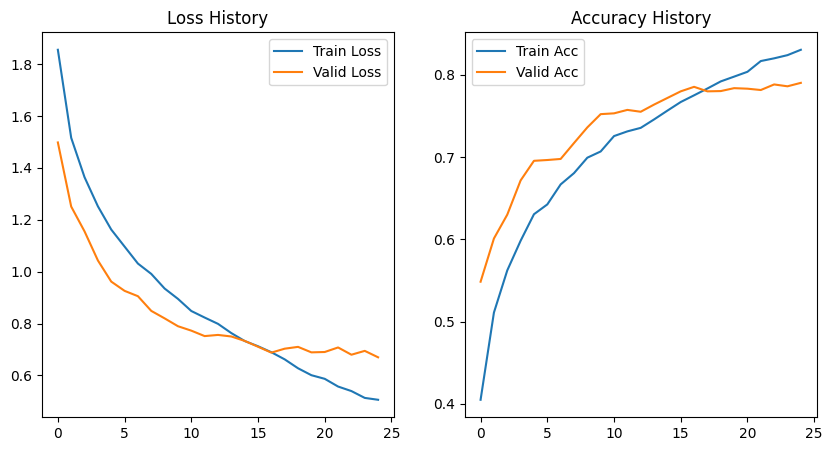

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(hist[0], label='Train Loss')
plt.plot(hist[1], label='Valid Loss')
plt.legend()
plt.title('Loss History')

plt.subplot(1, 2, 2)
plt.plot(hist[2], label='Train Acc')
plt.plot(hist[3], label='Valid Acc')
plt.legend()
plt.title('Accuracy History')
plt.show()

In [ ]:
images = os.listdir('/content/dataset')
images

['battery.PNG',
 'paper.PNG',
 'trash.PNG',
 'biological.PNG',
 'green glass.PNG',
 'whiteGlass.PNG',
 'plastic.PNG',
 'cardboard.PNG',
 'clothes.PNG',
 'brown glass.PNG',
 'metal.PNG',
 'shoes.PNG']

In [ ]:
print(full_datasets.class_to_idx)


{'battery': 0, 'biological': 1, 'brown-glass': 2, 'cardboard': 3, 'clothes': 4, 'green-glass': 5, 'metal': 6, 'paper': 7, 'plastic': 8, 'shoes': 9, 'trash': 10, 'white-glass': 11}


In [ ]:
classes = [
    'battery',
    'biological',
    'brown glass',
    'cardboard',
    'clothes',
    'green glass',
    'metal',
    'paper',
    'plastic',
    'shoes',
    'trash',
    'white glass'
]

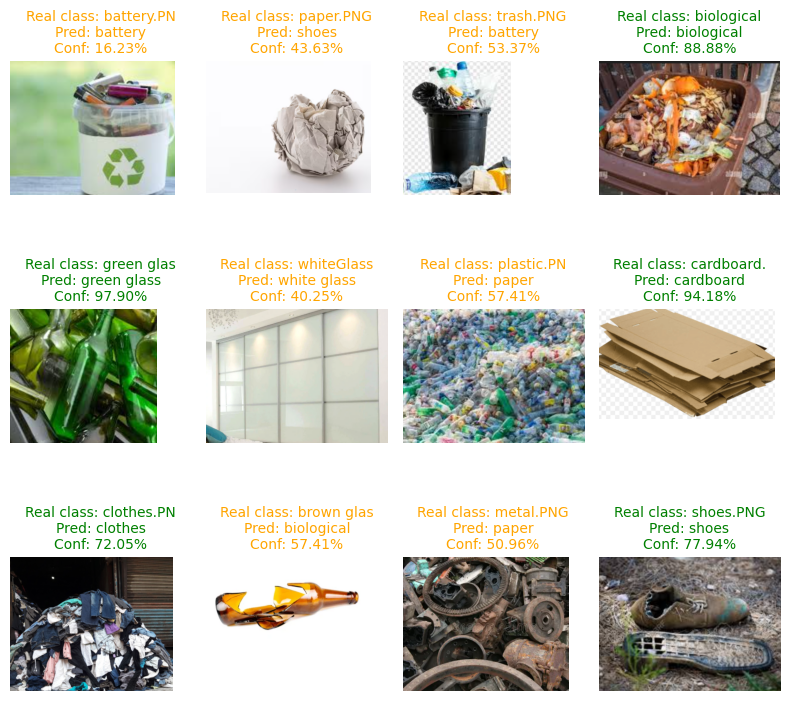

In [ ]:
folder_path = '/content/dataset'


fig, axes = plt.subplots(3, 4, sharex=True, sharey=True, figsize=(8,8))
axes = axes.flatten()

model.eval()

for i, image in enumerate(images):
  if i >= 12: break

  path = os.path.join(folder_path, image)
  img = Image.open(path).convert('RGB')

  img_tensor = transform(img).unsqueeze(0).to(device)

  with torch.no_grad():
        output = model(img_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
        probs = torch.nn.functional.softmax(output, dim=1)
        confidence = probs[0][pred_idx].item()

  axes[i].imshow(img)
  axes[i].set_title(f"Real class: {image[:10]}\nPred: {classes[pred_idx]}\nConf: {confidence:.2%}",
                      fontsize=10,
                      color='green' if confidence > 0.7 else 'orange')
  axes[i].axis('off')

plt.tight_layout()
plt.show()